## Cost Function and Gradient Descent

In [1]:
# Import NumPy for numerical calculations
import numpy as np

# Import math for mathematical operations
import math

# Import copy for copying variables
import copy

# Import Matplotlib for plotting graphs
import matplotlib.pyplot as plt

## Problem Statement

You would like a model which can predict housing prices given the size of the house.  
Let's use the following data


| Size (1000 sqft)     | Price (INR in Lakhs) |
| -------------------| ------------------------ |
| 1                 | 30                      |
| 2                  | 50                      |
| 3                  | 68                      |
| 4                  | 75                      |
| 5                  | 100                      |

In [8]:
# Training data
# x_train represents house size in 1000 square feet
x_train = np.array([1.0, 2.0, 3.0, 4.0, 5.0])

# y_train represents house price
# Price is given in INR Lakhs according to the problem statement
y_train = np.array([30.0, 50.0, 68.0, 75.0, 100.0])

## Computing Cost
The term 'cost' in this assignment might be a little confusing since the data is housing cost. Here, cost is a measure how well our model is predicting the target price of the house. The term 'price' is used for housing data.

The equation for cost with one variable is:
  $$J(θ_0, θ_1) = \frac{1}{2m} \sum\limits_{i = 0}^{m-1} (h(x^{(i)}) - y^{(i)})^2 \tag{1}$$

where
  $$h(x^{(i)}) = θ_0 + θ_1x^{(i)} \tag{2}$$
  
- $h(x^{(i)})$ is our prediction for example $i$ using parameters $θ_0, θ_1$.  
- $(h(x^{(i)}) -y^{(i)})^2$ is the squared difference between the target value and the prediction.   
- These differences are summed over all the $m$ examples and divided by `2m` to produce the cost, $J(θ_0, θ_1)$. This cost is mean squared error (MSE). Dividing by m and 2m is the same. 2m just yields smaller numbers for easier computations.

- Sometimes, $θ_0$ is also referred as Bias(b) and $θ_1$ onwards as Weights(w). We will use b, w in following sections.


The code below calculates cost by looping over each example. In each loop:
- `h_x`, a prediction is calculated
- the difference between the target and the prediction is calculated and squared.
- this is added to the total cost.

In [9]:
def compute_cost(x, y, b, w):
    """
    Computes the cost function for linear regression.

    Parameters:
        x : input training data
        y : target values
        b : bias/intercept
        w : weight/slope

    Returns:
        total_cost : calculated cost
    """

    # Number of training examples
    m = x.shape[0]

    # Variable to store the sum of squared errors
    cost_sum = 0

    # Loop through every training example
    for i in range(m):

        # Calculate the predicted value using:
        # h(x) = w*x + b
        h_x = w * x[i] + b

        # Calculate the squared error
        # Error = prediction - actual value
        cost = (h_x - y[i]) ** 2

        # Add the current cost to total cost
        cost_sum = cost_sum + cost

    # Calculate final cost using:
    # J(w,b) = 1/(2m) * sum((h(x) - y)^2)
    total_cost = (1 / (2 * m)) * cost_sum

    # Return the total cost
    return total_cost

<a name="toc_40291_2.1"></a>
## Gradient descent summary
So far in this course, you have developed a linear model that predicts $h(x^{(i)})$:
$$h(x^{(i)}) = wx^{(i)} + b \tag{1}$$
In linear regression, you utilize input training data to fit the parameters $w$,$b$ by minimizing a measure of the error between our predictions $h(x^{(i)})$ and the actual data $y^{(i)}$. The measure is called the $cost$, $J(w,b)$. In training you measure the cost over all of our training samples $x^{(i)},y^{(i)}$
$$J(w,b) = \frac{1}{2m} \sum\limits_{i = 0}^{m-1} (h(x^{(i)}) - y^{(i)})^2\tag{2}$$


`Gradient descent` is as follows:

$$\begin{align*} \text{repeat}&\text{ until convergence:} \; \lbrace \newline
\;  w &= w -  \alpha \frac{\partial J(w,b)}{\partial w} \tag{3}  \; \newline
 b &= b -  \alpha \frac{\partial J(w,b)}{\partial b}  \newline \rbrace
\end{align*}$$
where, parameters $w$, $b$ are updated simultaneously.  
To make it easier for you, the paritial derivatives are calculated:
$$
\begin{align}
\frac{\partial J(w,b)}{\partial w}  &= \frac{1}{m} \sum\limits_{i = 0}^{m-1} (h(x^{(i)}) - y^{(i)})x^{(i)} \tag{4}\\
  \frac{\partial J(w,b)}{\partial b}  &= \frac{1}{m} \sum\limits_{i = 0}^{m-1} (h(x^{(i)}) - y^{(i)}) \tag{5}\\
\end{align}
$$

Here *simultaneously* means that you calculate the partial derivatives for all the parameters before updating any of the parameters.

<a name="toc_40291_2.2"></a>
## Implement Gradient Descent
You will implement gradient descent algorithm for one feature. You will need three functions.
- `compute_gradient` has been implemented using equation (4) and (5) above
- `compute_cost` implementing equation (2) above, which you have completed
- `gradient_descent`, utilizing compute_gradient and compute_cost

Conventions:
- The naming of python variables containing partial derivatives follows this pattern,$\frac{\partial J(w,b)}{\partial b}$  will be `dj_db`.
- w.r.t is With Respect To, as in partial derivative of $J(wb)$ With Respect To $b$.


In [11]:
def compute_gradient(x, y, w, b):
    """
    Computes the gradient for linear regression.

    Parameters:
        x : input training data
        y : target values
        w : weight
        b : bias

    Returns:
        dj_dw : derivative of cost with respect to w
        dj_db : derivative of cost with respect to b
    """

    # Number of training examples
    m = x.shape[0]

    # Initialize gradients
    dj_dw = 0
    dj_db = 0

    # Calculate gradient for every training example
    for i in range(m):

        # Calculate prediction
        # h(x) = w*x + b
        h_x = w * x[i] + b

        # Calculate gradient with respect to w
        dj_dw_i = (h_x - y[i]) * x[i]

        # Calculate gradient with respect to b
        dj_db_i = h_x - y[i]

        # Add individual gradients
        dj_db += dj_db_i
        dj_dw += dj_dw_i

    # Calculate average gradient
    dj_dw = dj_dw / m
    dj_db = dj_db / m

    # Return gradients
    return dj_dw, dj_db

<a name="toc_40291_2.5"></a>
###  Gradient Descent
Now that gradients can be computed,  gradient descent, described in equation (3) above can be implemented below in `gradient_descent`. The details of the implementation are described in the comments. Below, you will utilize this function to find optimal values of $w$ and $b$ on the training data.

In [12]:
def gradient_descent(x, y, w_in, b_in, alpha, num_iters,
                     cost_function, gradient_function):
    """
    Performs gradient descent to find optimal values of w and b.

    Parameters:
        x : input training data
        y : target values
        w_in : initial weight
        b_in : initial bias
        alpha : learning rate
        num_iters : number of iterations
        cost_function : function used to calculate cost
        gradient_function : function used to calculate gradients

    Returns:
        w : final optimized weight
        b : final optimized bias
        J_history : history of cost values
        p_history : history of w and b values
    """

    # Copy initial weight so original value is not changed
    w = copy.deepcopy(w_in)

    # Store cost values after every iteration
    J_history = []

    # Store parameter values after every iteration
    p_history = []

    # Set initial bias
    b = b_in

    # Set initial weight
    w = w_in

    # Run gradient descent for specified number of iterations
    for i in range(num_iters):

        # Calculate gradients for current w and b
        dj_dw, dj_db = gradient_function(x, y, w, b)

        # Update weight using gradient descent formula
        # w = w - alpha * derivative
        w = w - alpha * dj_dw

        # Update bias using gradient descent formula
        # b = b - alpha * derivative
        b = b - alpha * dj_db

        # Store cost and parameters
        if i < 100000:

            # Calculate current cost
            cost = cost_function(x, y, b, w)

            # Store cost history
            J_history.append(cost)

            # Store current weight and bias
            p_history.append([w, b])

        # Print progress after every 10% of iterations
        if i % math.ceil(num_iters / 10) == 0:

            print(
                f"Iteration {i:4}: Cost {J_history[-1]:0.2e} ",
                f"dj_dw: {dj_dw: 0.3e}, dj_db: {dj_db: 0.3e} ",
                f"w: {w: 0.3e}, b: {b: 0.5e}"
            )

    # Return final values and history
    return w, b, J_history, p_history

## Run Gradient Descent

In [13]:
# Initialize weight
w_init = 0

# Initialize bias
b_init = 0

# Number of gradient descent iterations
iterations = 10000

# Learning rate
tmp_alpha = 1.0e-2

# Run gradient descent
w_final, b_final, J_hist, p_hist = gradient_descent(
    x_train,
    y_train,
    w_init,
    b_init,
    tmp_alpha,
    iterations,
    compute_cost,
    compute_gradient
)

# Print the final optimized values of w and b
print(
    f"(w,b) found by gradient descent: "
    f"({w_final:8.4f},{b_final:8.4f})"
)

Iteration    0: Cost 1.84e+03  dj_dw: -2.268e+02, dj_db: -6.460e+01  w:  2.268e+00, b:  6.46000e-01
Iteration 1000: Cost 6.36e+00  dj_dw:  8.433e-02, dj_db: -3.045e-01  w:  1.700e+01, b:  1.33020e+01
Iteration 2000: Cost 6.08e+00  dj_dw:  1.553e-02, dj_db: -5.607e-02  w:  1.659e+01, b:  1.47689e+01
Iteration 3000: Cost 6.07e+00  dj_dw:  2.860e-03, dj_db: -1.033e-02  w:  1.652e+01, b:  1.50390e+01
Iteration 4000: Cost 6.07e+00  dj_dw:  5.268e-04, dj_db: -1.902e-03  w:  1.650e+01, b:  1.50888e+01
Iteration 5000: Cost 6.07e+00  dj_dw:  9.702e-05, dj_db: -3.503e-04  w:  1.650e+01, b:  1.50979e+01
Iteration 6000: Cost 6.07e+00  dj_dw:  1.787e-05, dj_db: -6.451e-05  w:  1.650e+01, b:  1.50996e+01
Iteration 7000: Cost 6.07e+00  dj_dw:  3.291e-06, dj_db: -1.188e-05  w:  1.650e+01, b:  1.50999e+01
Iteration 8000: Cost 6.07e+00  dj_dw:  6.060e-07, dj_db: -2.188e-06  w:  1.650e+01, b:  1.51000e+01
Iteration 9000: Cost 6.07e+00  dj_dw:  1.116e-07, dj_db: -4.029e-07  w:  1.650e+01, b:  1.51000e+01


### Cost versus iterations of gradient descent
A plot of cost versus iterations is a useful measure of progress in gradient descent. Cost should always decrease in successful runs. The change in cost is so rapid initially, it is useful to plot the initial decent on a different scale than the final descent. In the plots below, note the scale of cost on the axes and the iteration step.

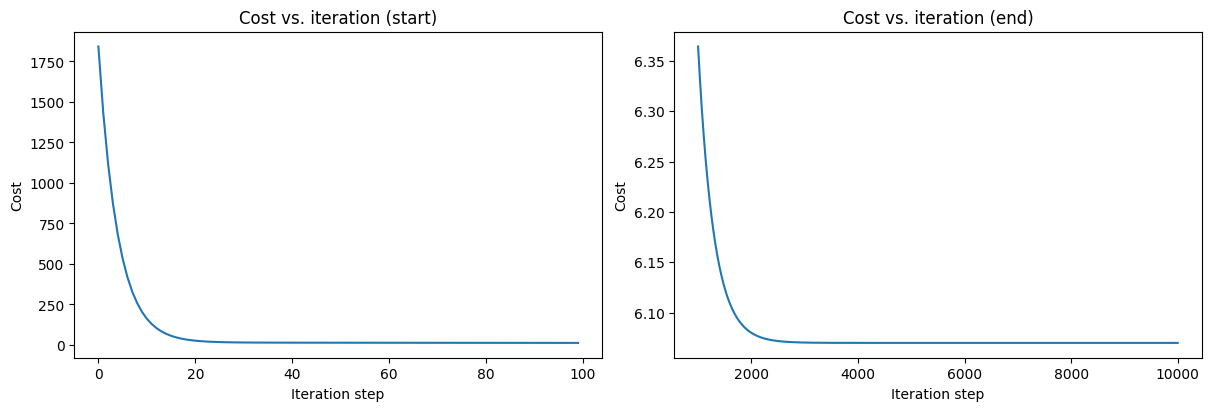

In [14]:
# Create two plots
fig, (ax1, ax2) = plt.subplots(
    1, 2,
    constrained_layout=True,
    figsize=(12, 4)
)

# Plot cost for the first 100 iterations
ax1.plot(J_hist[:100])

# Plot cost for later iterations
ax2.plot(
    1000 + np.arange(len(J_hist[1000:])),
    J_hist[1000:]
)

# Set titles
ax1.set_title("Cost vs. iteration (start)")
ax2.set_title("Cost vs. iteration (end)")

# Set y-axis labels
ax1.set_ylabel("Cost")
ax2.set_ylabel("Cost")

# Set x-axis labels
ax1.set_xlabel("Iteration step")
ax2.set_xlabel("Iteration step")

# Display the plots
plt.show()

### Predictions
Now that you have discovered the optimal values for the parameters $w$ and $b$, you can now use the model to predict housing values based on our learned parameters. You will notice the predicted values are nearly the same as the training values for the same housing, and predictions for newer values also are inline with the training data.

In [15]:
# -------------------------------------------------------
# PREDICTIONS
# -------------------------------------------------------

# For 1000 sqft:
# Since x_train is measured in 1000 sqft,
# 1000 sqft = 1.0
prediction_1000 = w_final * 1.0 + b_final

# For 2000 sqft:
# 2000 sqft = 2.0
prediction_2000 = w_final * 2.0 + b_final

# For 1750 sqft:
# 1750 sqft = 1.75
prediction_1750 = w_final * 1.75 + b_final


# Display predictions
print(
    f"1000 sqft house prediction "
    f"{prediction_1000:0.1f} Thousand INR"
)

print(
    f"2000 sqft house prediction "
    f"{prediction_2000:0.1f} Thousand INR"
)

print(
    f"1750 sqft house prediction "
    f"{prediction_1750:0.1f} Thousand INR"
)

1000 sqft house prediction 31.6 Thousand INR
2000 sqft house prediction 48.1 Thousand INR
1750 sqft house prediction 44.0 Thousand INR
